Loading model from /home/U116med/wch_code/cascade/models/prototype_cascade/baseline_prototype_fb_44/best.pth...
Model decoder:  created, param count: 1913515


/tmp/ipykernel_249481/483061516.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cfg['model_path'], map_location=device)


Found 798 test images.
Accumulating activation maps...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 798/798 [00:23<00:00, 33.64it/s]


Plotting heatmaps...
Saved analysis to ./analysis_results/spatial_bias_with_gt.png


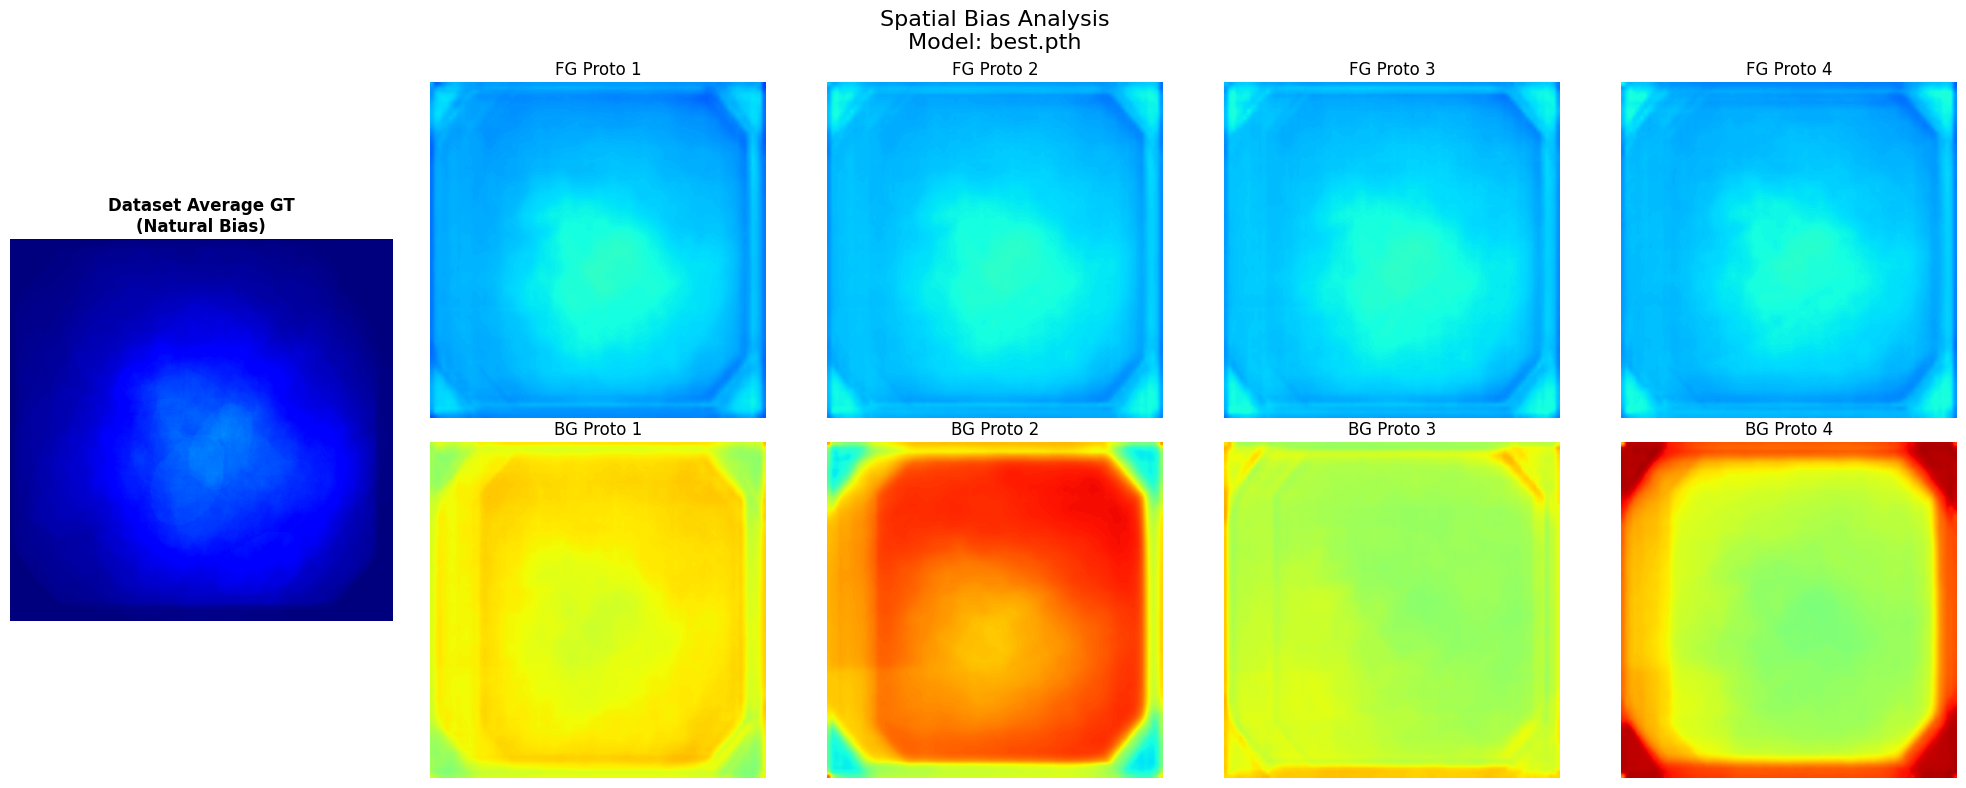

In [2]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from lib.networks_prototype import Prototype_CASCADE
from utils.dataloader import test_dataset

def analyze_spatial_bias(cfg):
    # 1. 初始化
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs(cfg['output_dir'], exist_ok=True)
    
    print(f"Loading model from {cfg['model_path']}...")
    model = Prototype_CASCADE(num_fg=cfg['num_fg'], num_bg=cfg['num_bg']).to(device)
    
    if os.path.exists(cfg['model_path']):
        state_dict = torch.load(cfg['model_path'], map_location=device, weights_only=True)
        model.load_state_dict(state_dict, strict=False)
    else:
        print(f"Error: Model path not found: {cfg['model_path']}")
        return
    model.eval()
    
    # 2. 準備數據集
    test_loader = test_dataset(cfg['image_root'], cfg['gt_root'], cfg['img_size'])
    print(f"Found {test_loader.size} test images.")
    
    # 3. 初始化累積器
    # accumulator shape: (K, H, W)
    num_prototypes = cfg['num_fg'] + cfg['num_bg']
    spatial_accumulator = torch.zeros((num_prototypes, cfg['img_size'], cfg['img_size']), device=device)
    
    # [新增] GT 累積器：用來看數據集原本的分佈長怎樣
    gt_accumulator = torch.zeros((1, cfg['img_size'], cfg['img_size']), device=device)
    
    print("Accumulating activation maps...")
    with torch.no_grad():
        for i in tqdm(range(test_loader.size)):
            image, gt, name = test_loader.load_data()
            
            image = image.cuda() # (1, 3, H, W)
            
            # GT 處理 (0~255 -> 0~1)
            gt = np.asarray(gt, np.float32)
            gt /= (gt.max() + 1e-8)
            gt_tensor = torch.from_numpy(gt).to(device).unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
            
            # Resize GT to target size just in case (保持 4D 進行插值)
            if gt_tensor.shape[-2:] != (cfg['img_size'], cfg['img_size']):
                 gt_tensor = F.interpolate(gt_tensor, size=(cfg['img_size'], cfg['img_size']), mode='nearest')
            
            # [修正點]：將 gt_tensor 從 (1, 1, H, W) 變成 (1, H, W) 再累加
            gt_accumulator += gt_tensor.squeeze(0)
            # Forward
            # 獲取 similarity_map_high: (1, K, H, W)
            _, similarity_map = model(image)
            
            # [關鍵修正] 強制插值到累積器的大小，避免尺寸不匹配
            if similarity_map.shape[-2:] != (cfg['img_size'], cfg['img_size']):
                similarity_map = F.interpolate(similarity_map, size=(cfg['img_size'], cfg['img_size']), 
                                               mode='bilinear', align_corners=False)
            
            # Cosine Sim [-1, 1] -> Normalize to [0, 1] for heatmap visualization
            sim_norm = (similarity_map[0] + 1) / 2.0
            
            spatial_accumulator += sim_norm

    # 4. 計算平均
    avg_spatial_map = spatial_accumulator / test_loader.size # (K, H, W)
    avg_spatial_map = avg_spatial_map.cpu().numpy()
    
    avg_gt_map = gt_accumulator / test_loader.size # (1, H, W)
    avg_gt_map = avg_gt_map.cpu().numpy().squeeze()
    
    print("Plotting heatmaps...")
    
    # 5. 繪圖
    # 佈局: 2行 (FG/BG) + 1個獨立的 GT 分佈圖
    cols = max(cfg['num_fg'], cfg['num_bg'])
    
    # 建立一個大圖，包含 GT 分佈
    fig = plt.figure(figsize=(4 * (cols + 1), 8))
    plt.suptitle(f"Spatial Bias Analysis\nModel: {os.path.basename(cfg['model_path'])}", fontsize=16)
    
    # 定義 Grid Spec
    gs = fig.add_gridspec(2, cols + 1) # +1 是為了放 GT Reference

    # --- 繪製 Dataset Average GT (放在最左邊當作 Reference) ---
    ax_gt = fig.add_subplot(gs[:, 0])
    ax_gt.imshow(avg_gt_map, cmap='jet', vmin=0, vmax=1)
    ax_gt.set_title("Dataset Average GT\n(Natural Bias)", fontweight='bold')
    ax_gt.axis('off')

    # --- 繪製 Foreground Prototypes ---
    for k in range(cfg['num_fg']):
        ax = fig.add_subplot(gs[0, k + 1])
        heatmap = avg_spatial_map[k]
        im = ax.imshow(heatmap, cmap='jet', vmin=0, vmax=1) # 固定 scale 以便比較
        ax.set_title(f"FG Proto {k+1}")
        ax.axis('off')
        
    # --- 繪製 Background Prototypes ---
    for k in range(cfg['num_bg']):
        ax = fig.add_subplot(gs[1, k + 1])
        heatmap = avg_spatial_map[cfg['num_fg'] + k]
        im = ax.imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        ax.set_title(f"BG Proto {k+1}")
        ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(cfg['output_dir'], 'spatial_bias_with_gt.png')
    plt.savefig(save_path)
    print(f"Saved analysis to {save_path}")

if __name__ == '__main__':
    config = {
        'model_path': '/home/U116med/wch_code/cascade/models/prototype_cascade/baseline_prototype_fb_44/best.pth',

        'image_root': '/home/U116med/data/polyp/TestDataset/test/images/', 
        'gt_root': '/home/U116med/data/polyp/TestDataset/test/masks/',
        
        'img_size': 352,
        'num_fg': 4,
        'num_bg': 4,
        
        'output_dir': './analysis_results/'
    }
    
    analyze_spatial_bias(config)